In [1]:
import numpy as np
import pandas as pd

In [2]:
import yfinance as yf

ticker = 'MSFT'
table = yf.download(ticker, start='2015-01-01', end='2025-05-10')
table

/tmp/ipykernel_2824/2319727582.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  table = yf.download(ticker, start='2015-01-01', end='2025-05-10')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2015-01-02,39.767696,40.329003,39.580597,39.682651,27913900
2015-01-05,39.401989,39.742173,39.333950,39.436005,39673900
2015-01-06,38.823666,39.759174,38.730114,39.444504,36447900
2015-01-07,39.316940,39.512547,38.687599,39.104324,29114100
2015-01-08,40.473564,40.609638,39.733662,39.759175,29645200
...,...,...,...,...,...
2025-05-05,432.856262,436.160950,428.827080,429.581315,20136100
2025-05-06,430.017914,434.404346,427.894188,428.916362,15104200


In [3]:
data = table[['Close']]
data

Price,Close
Ticker,MSFT
Date,
2015-01-02,39.767696
2015-01-05,39.401989
2015-01-06,38.823666
2015-01-07,39.316940
2015-01-08,40.473564
...,...
2025-05-05,432.856262
2025-05-06,430.017914


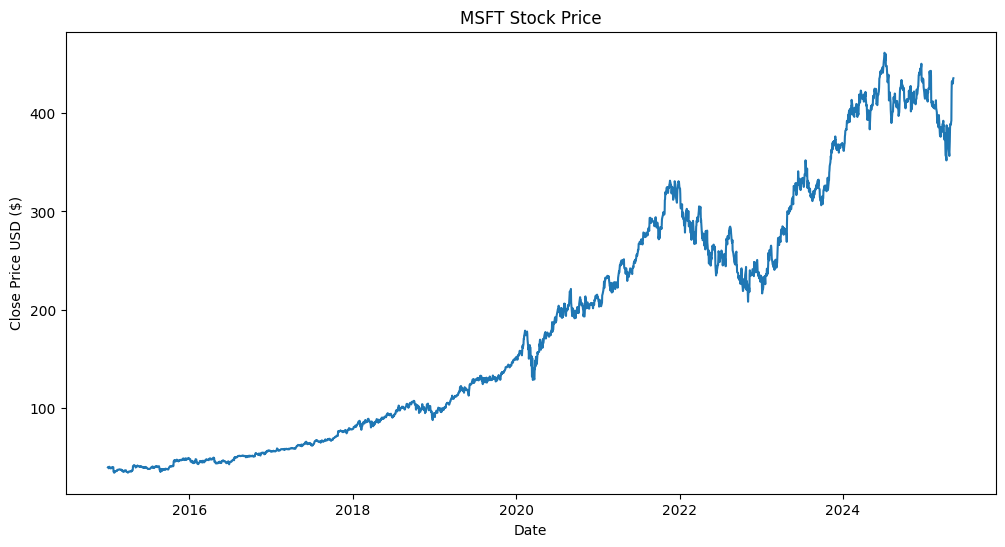

In [4]:
import matplotlib.pyplot as plt

# 📊 Visualize Closing Price
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title(f"{ticker} Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price USD ($)")
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data

array([[0.01266845],
       [0.01181192],
       [0.01045742],
       ...,
       [0.92677371],
       [0.93797696],
       [0.93927854]])

In [6]:
# ✂️ Split into Train and Test
sequence_length = 120
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - sequence_length:]

In [7]:
# 🧠 Prepare Training Data
X_train, y_train = [], []
for i in range(sequence_length, len(train_data)):
    X_train.append(train_data[i-sequence_length:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [8]:
# 🧪 Prepare Testing Data
X_test, y_test = [], []
for i in range(sequence_length, len(test_data)):
    X_test.append(test_data[i-sequence_length:i, 0])
    y_test.append(test_data[i, 0])

X_test, y_test = np.array(X_test), np.array(y_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

# 🔧 Build LSTM Model
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(150, return_sequences=True),
    Dropout(0.5),
    LSTM(100, return_sequences=False),
    Dropout(0.3),
    Dense(64),
    Dense(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

In [10]:
model.fit(X_train, y_train, batch_size=64, epochs=10)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 483ms/step - loss: 0.0089
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 493ms/step - loss: 0.0012
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 492ms/step - loss: 9.9192e-04
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 520ms/step - loss: 8.4145e-04
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - loss: 7.3360e-04
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 480ms/step - loss: 7.0228e-04
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 495ms/step - loss: 7.2593e-04
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 479ms/step - loss: 6.4850e-04
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 501ms/step - loss: 5.9350e-04
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 493ms/step - loss: 6.5675e-04


In [11]:
# 📈 Predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step


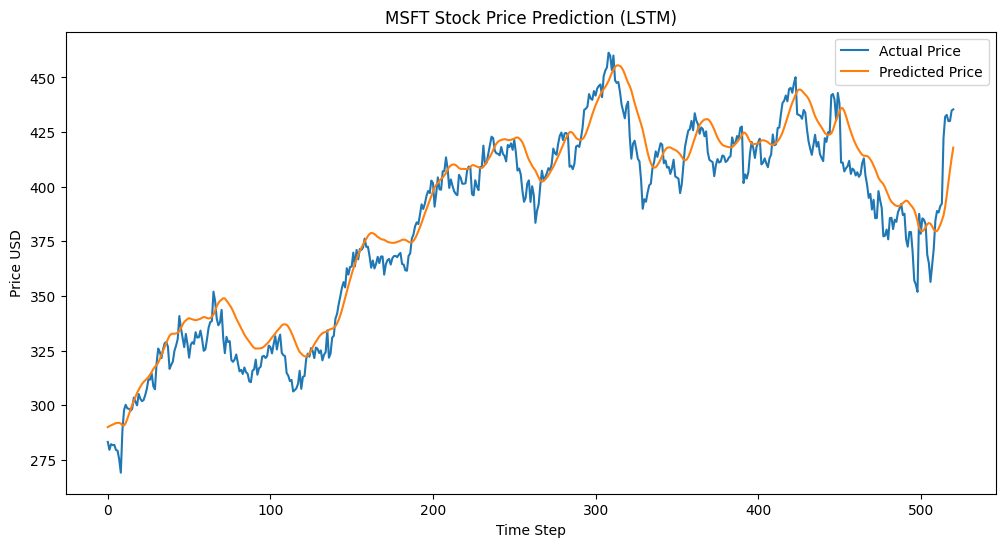

In [12]:
# 📊 Plot Results
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title(f"{ticker} Stock Price Prediction (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("Price USD")
plt.legend()
plt.show()

In [13]:
last_sequence = scaled_data[-sequence_length:]

# Reshape last sequence for LSTM input
last_sequence = np.reshape(last_sequence, (1, sequence_length, 1))

# 📈 Predict for the next 10 days
predicted_prices = []
for _ in range(10):  # Predict for the next 10 days
    predicted_price = model.predict(last_sequence)

    # Inverse transform to get the predicted price in the original scale
    predicted_price = scaler.inverse_transform(predicted_price)
    predicted_prices.append(predicted_price[0][0])

    # Reshape the predicted price to (1, 1, 1) and append it
    predicted_price_reshaped = np.reshape(predicted_price, (1, 1, 1))
    last_sequence = np.append(last_sequence[:, 1:, :], predicted_price_reshaped, axis=1)

# Output the predicted prices for the next 10 days
for i, price in enumerate(predicted_prices, 1):
    print(f"Predicted price for day {i}: ${price:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted price for day 1: $422.28
Predicted price for day 2: $629.84
Predicted price for day 3: $792.42
Predicted price for day 4: $899.86
Predicted price for day 5: $968.72
Predicted price for day 6: $1012.65
Predicted price for day 7: $1040.75
Predicted price for day 8: $1058.82
Predicted price for day 9: $1070.54
Predicted price for day 10: $1078.22
